In [1]:
%cd ../

from wag_toolkit.locations import Locations
import pandas as pd
import json
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit


True

### Wellcome

In [2]:
countries_class = pd.read_excel('geographies/CH_files/CLASS.xlsx', sheet_name='List of economies')
lmic_list = countries_class[countries_class['Income group'].isin(['Low income', 'Lower middle income', 'Upper middle income'])]
lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
lmic_list['Economy'] = lmic_list['Economy'].replace("Iran, Islamic Rep.", "Iran")
lmic_list['Economy'] = lmic_list['Economy'].replace("Congo, Dem. Rep.", "Democratic Republic of the Congo")

/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_21314/2822603552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_21314/2822603552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_21314/2822603552.py:5: SettingWithCo

In [3]:
dummy_query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication) RETURN * LIMIT 1"""
query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication)
            WHERE p.dimensions_publication_id IN {}
            RETURN p.dimensions_publication_id AS dimensions_publication_id, p.year AS year,
                a.institutions AS grid_id"""

In [ ]:
wt_ch = pd.read_excel('geographies/CH_files/C&HPublicationExtraction.xlsx', sheet_name='Combined Awards')
grants_ref = pd.read_excel('geographies/CH_files/Manual Tagging of Grants with C&H goals.xlsx', sheet_name='Total C&H Awards_SM tagging')
grants_ref = grants_ref[grants_ref['C&H/C&H in partnership/wider portfolio (new)'].isin(['C&H', 'C&H in partnership'])]
grants_list = list(set(grants_ref['Grant Reference'].to_list()))
wt_ch = wt_ch[wt_ch['Wellcome Grant Reference'].isin(grants_list)]
wt_pub_ids = list(set(wt_ch['Publication ID'].tolist()))

In [ ]:
# Uncomment for non-Wellcome funded publications

# all_ch = pd.read_parquet('geographies/CH_files/climate_health_intersection_just_ids.parquet')
# all_pub_ids = list(set(all_ch['publication_id'].tolist()))
# wt_pub_ids = list(set(all_pub_ids)-set(wt_pub_ids))

In [6]:
wt_ch_loc = Locations(dummy_query)
wt_ch_loc.lookup_query(query=query, lookup=wt_pub_ids)

wt_ch_loc._clean_grid_ids()
data =pd.DataFrame(wt_ch_loc.data)
data = data.explode("grid_id").dropna()
data

100%|██████████| 2/2 [00:11<00:00,  5.74s/it]


,dimensions_publication_id,year,grid_id
8,pub.1146763677,2022.0,grid.189504.1
9,pub.1146763677,2022.0,grid.8991.9
10,pub.1145226527,2022.0,grid.8991.9
11,pub.1145226527,2022.0,grid.16463.36
12,pub.1145226527,2022.0,grid.16463.36
...,...,...,...
8665,pub.1150724935,2022.0,grid.166341.7
8666,pub.1150724935,2022.0,grid.166341.7
8667,pub.1150724935,2022.0,grid.10692.3c
8668,pub.1150724935,2022.0,grid.166341.7


In [12]:
from wag_toolkit.utils import Neo4j

neo4j = Neo4j()

unique_grid_ids = list(data['grid_id'].unique())
query = f"""
MATCH (i:Institution)
WHERE i.grid_id IN {unique_grid_ids}
RETURN i.grid_id as grid_id, i.country as country
"""
neo4j.query(query, as_graph=False)
countries_df = pd.DataFrame(neo4j.data)

100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


In [13]:
merged_data = pd.merge(data, countries_df, on='grid_id', how='left')
merged_data['country'] = merged_data['country'].str.strip("[']")
merged_data.drop_duplicates(ignore_index=True, inplace=True)
merged_data

,dimensions_publication_id,year,grid_id,country
0,pub.1146763677,2022.0,grid.189504.1,United States
1,pub.1146763677,2022.0,grid.8991.9,United Kingdom
2,pub.1145226527,2022.0,grid.8991.9,United Kingdom
3,pub.1145226527,2022.0,grid.16463.36,South Africa
4,pub.1145226527,2022.0,grid.5846.f,United Kingdom
...,...,...,...,...
3056,pub.1135471275,2021.0,grid.1013.3,Australia
3057,pub.1135748975,2021.0,grid.8991.9,United Kingdom
3058,pub.1150724935,2022.0,grid.166341.7,United States
3059,pub.1150724935,2022.0,grid.423606.5,Argentina


In [ ]:
pubs_data = {}

for publication in merged_data.dimensions_publication_id.unique():
    df = merged_data[merged_data['dimensions_publication_id'] == publication]
    
    if not df.empty and 'year' in df.columns:
        year_value = df['year'].iloc[0] 
        
        if year_value not in pubs_data:
            pubs_data[year_value] = {'cross-country': 0, 'lmic': 0, 'total': 0}
        
        # Check if there are multiple unique countries
        if len(df['country'].unique()) > 1:
            pubs_data[year_value]['cross-country'] += 1
        
        # Check if any country in the publication is in the lmic_list
        if set(df['country'].unique()) & set(lmic_list['Economy']):
            pubs_data[year_value]['lmic'] += 1
        
        pubs_data[year_value]['total'] += 1
    else:
        print(f"Skipping publication {publication} due to missing 'year' data.")


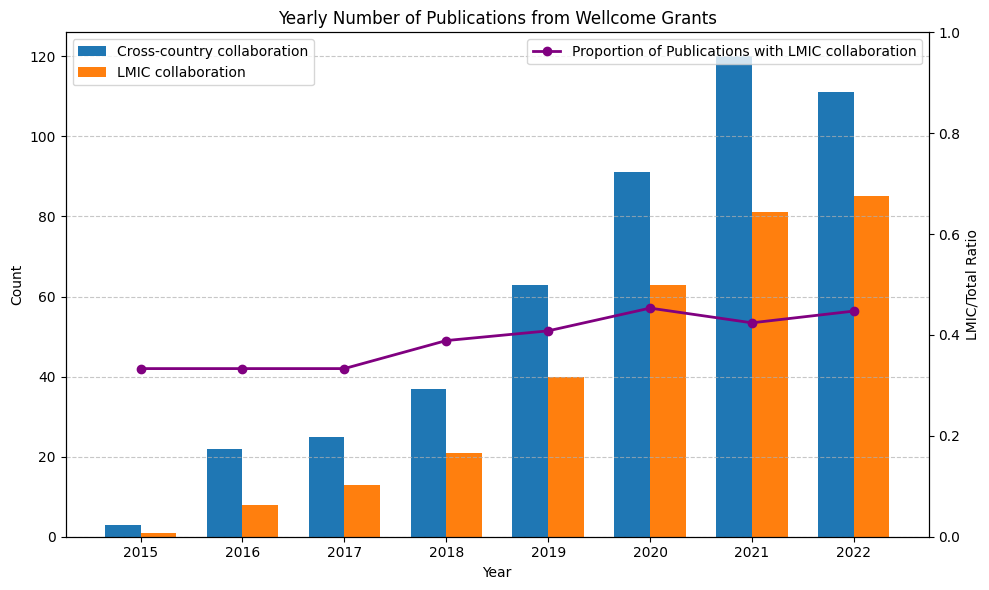

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Extract years and data for plotting
years = sorted(pubs_data.keys())[:-1]  
years_int = [int(year) for year in years] 
cross_country = [pubs_data[year]['cross-country'] for year in years]
lmic = [pubs_data[year]['lmic'] for year in years]
total = [pubs_data[year]['total'] for year in years]

# Calculate the ratio of 'lmic' to 'total'
lmic_to_total_ratio = [pubs_data[year]['lmic'] / pubs_data[year]['total'] for year in years]


bar_width = 0.35
x = np.arange(len(years))
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(x - bar_width / 2, cross_country, bar_width, label='Cross-country collaboration')
ax1.bar(x + bar_width / 2, lmic, bar_width, label='LMIC collaboration')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.set_title('Yearly Number of Publications from Wellcome Grants')
ax1.set_xticks(x)
ax1.set_xticklabels(years_int)  
ax1.legend()
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()  
ax2.plot(x, lmic_to_total_ratio, color='purple', marker='o', label='Proportion of Publications with LMIC collaboration', linewidth=2)
ax2.set_ylabel('LMIC/Total Ratio')
ax2.set_ylim(0,1)
ax2.legend()

plt.tight_layout()
plt.show()